# Federated learning: ECI 2026 Project

This is the [final optional project](http://ichatz.me/Site/FederatedLearningECI2026Project) for the course Federated Learning taught by [Ioannis Chatzigiannakis](http://ichatz.me/Site/Home) at the Escuelas de Ciencias Informáticas in July 2026. 

The course itself followed the idea of dataset descentralization to perform Machine Learning to avoid providing sensitive (raw) data to privately-owned servers, during the course we also tackled the problems regarding non-IIDness, adversarial clients, privacy & security. 

It was overall a fantastic course that really sparked my interest in what is usually an underlooked aspect of digitalization, how we protect our data & the trust we place in big corporations.

With that being said, the objective here is to simulate a small federated learning scenario


## SETUP

First we need to install Tensorflow (and it's datasets) & MatPlotLib 

In [1]:
!pip install -q matplotlib
!pip install -q tensorflow tensorflow_probability[tf]
!pip install -q numpy
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install -q scikit-learn

Then we import it

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torchvision
import tensorflow_probability as tfp
import numpy as np
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy

## Dataset

I'm going to be using [CIFAR10](https://www.tensorflow.org/datasets/catalog/cifar10?hl=es), a dataset containing 60000 32x32 colour images uniformly distributed amongst 10 classes. 

We want an equal label-wise distribution using a **60/10/30** split for training, validation & test, for that reason we must stratify the split using the labels 

> The dataset itself is pre-split so we need to recombine it and then split it

In [3]:
train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=True)
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=True)

train_labels = torch.from_numpy(np.array(train_data.targets)).long()
test_labels = torch.from_numpy(np.array(test_data.targets)).long()

train_images = torch.from_numpy(train_data.data)
test_images = torch.from_numpy(test_data.data)

train_images_normalized = (train_images).float() / 255.0   
train_images_normalized = train_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

test_images_normalized = (test_images).float() / 255.0   
test_images_normalized = test_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

train_labels = (train_labels).long()   
test_labels = (test_labels).long()     

images = torch.cat([train_images_normalized, test_images_normalized], dim=0)
labels = torch.cat([train_labels, test_labels], dim=0)

# First we take the 60% split
X_train, X_temp, Y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.40,      
    random_state=42,
    stratify=labels   
)

# Then we split the remaining 40% of the dataset into 10/30
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.75,      
    random_state=42,
    stratify=y_temp      
)

train_data = TensorDataset(X_train, Y_train)
val_data   = TensorDataset(X_val, Y_val)
test_data  = TensorDataset(X_test, Y_test)

print(train_data.tensors[0].shape)  
print(train_data.tensors[1].shape)


100.0%


torch.Size([36000, 3, 32, 32])
torch.Size([36000])


### Dataset Analysis

Now we can plot and visualize some of the data distribution, in particular we can see

1.  Histogram of the classes
2.  Few samples

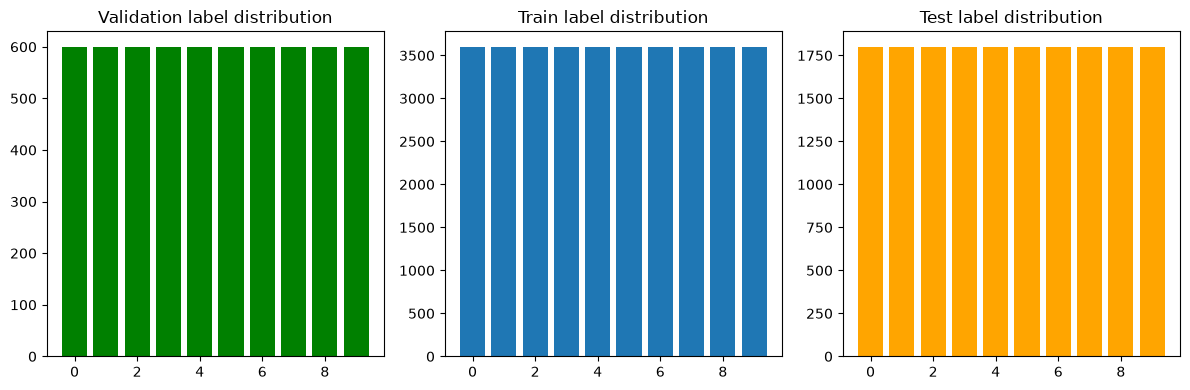

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(np.unique_counts(Y_val).values, np.unique_counts(Y_val).counts, color="green")
axes[0].set_title("Validation label distribution")
axes[1].bar(np.unique_counts(Y_train).values, np.unique_counts(Y_train).counts)
axes[1].set_title("Train label distribution")
axes[2].bar(np.unique_counts(Y_test).values, np.unique_counts(Y_test).counts, color="orange")
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

As we can see there is no quantity skewness because all labels have exactly 6000 samples (although we will split it into non-IID scenarios).

Let's visualize some samples of the images to get a general idea of what they look like

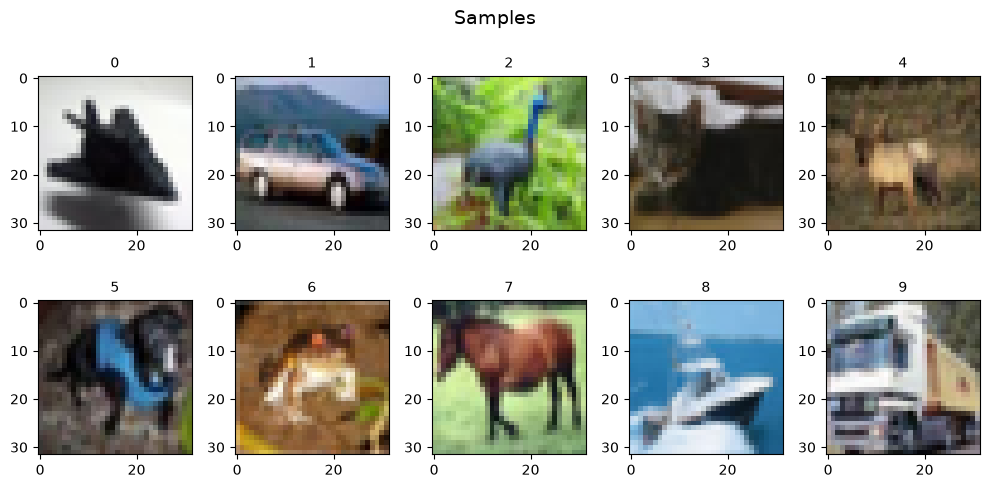

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

axes_flat = axes.flatten()

for i in range(10):
    j = 0
    while train_labels[j] != i:
        j += 1
        
    if j < len(train_labels):
        ax = axes_flat[i]
        ax.imshow(train_images[j])
        ax.set_title(f"{train_labels[j]}", fontsize=10)

plt.suptitle("Samples", fontsize=14)
plt.tight_layout()
plt.show()

## Centralized Baseline

As we attempt to showcase the effectiveness of Federated Learning (& the challenges it poses) we need a baseline for comparison, in this case the obvious thing to do is to have a standard centralized model. 

### Model construction

Now we will build a 2D Sequential Convolutional Neural Network 

<details>
<summary><b>Sources</b></summary>

* Model:    
    -   [Sequential CNNs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html)
* Layers: 
    -   [Conv2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
    -   [AveragePooling2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.AvgPool2d.html#torch.nn.AvgPool2d)
    -   [Flatten](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Flatten.html#torch.nn.Flatten)
    -   [Linear (Dense)](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Linear.html#torch.nn.Linear)
    -   [Dropout](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html#torch.nn.Dropout)
*   Activation Functions:
    -   [softmax](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Softmax.html)
    -   [relu](https://docs.pytorch.org/docs/2.13/generated/torch.nn.ReLU.html)

</details>

We define our model's layers, looking at the dataset's shape

In [6]:
print(train_data.tensors[0].shape) #X shape
print(train_data.tensors[1].shape) #Y shape

torch.Size([36000, 3, 32, 32])
torch.Size([36000])


In [7]:
initial_model = nn.Sequential(

    #Feature Extraction
    nn.Conv2d(3, 8, (7,7), padding="same", stride=1), #3 channels (image has color, otherwise it'd be 1 channel?)
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(8, 16, (5,5), padding="same", stride=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(16, 32, (3,3), padding="same", stride=1),
    nn.ReLU(),

    #Classifier
    nn.Flatten(), 
    nn.Dropout(p=0.3),
    nn.Linear(2048, 128), #value 2048 is because of 32x32x32x3 / 2 / 2 
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.Linear(64,10),
    nn.LogSoftmax(dim=1)
)

### Train & Test steps

Now with our model properly defined we have to define what training and testing means

Training will take each (image,label) tuple and make the model predict the label, after that we calculate the loss with the truth and then perform backpropagation.

Testing will also take (image, label) tuples, predict a label, validate the result and finally calculate the overall guess rate 

In [8]:


def train(model, optimizer, dataLoader, loss_fn):
    model.train()
    total_loss = 0
    dataset_size = len(dataLoader.dataset)
    for (X, y) in (dataLoader):

        # Predict then calculate loss
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        #Calculate loss 
        total_loss += loss.item() * X.size(0)

    avg_loss = total_loss/dataset_size

    return model, avg_loss

def test(model, dataLoader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    dataset_size = len(dataLoader.dataset)

    #Using .no_grad makes sure the model doesn't actually learn from the test 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            #Calculate loss 
            loss = loss_fn(pred, y)
            total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / dataset_size
    accuracy = correct / dataset_size

    return (accuracy, avg_loss)



### Model Training 

With all pieces in place we can now perform an optimized training routine that will track accuracy over the validation set and restore the best weights if no improvements are seen after 3 epochs, we will utilize 2 optimizers and compare the results 

In [9]:
def run_model(model, optimizer, epochs, train_dataloader, val_dataloader):

    best_model = copy.deepcopy(model)
    best_model_accuracy = 0
    stall_count = 0
    train_accAndloss_arr = []
    val_accAndloss_arr = []

    for t in range(epochs):
        model, current_loss = train(model, optimizer, train_dataloader, nn.NLLLoss())  #We train the model
        (model_accuracy, current_loss) = test(model, val_dataloader, nn.NLLLoss())    #Get it's validation accuracy

        val_accAndloss_arr.append((model_accuracy,current_loss))    
        train_accAndloss_arr.append(test(model, train_dataloader, nn.NLLLoss()))        #Calculate accuracy on train dataset (for over/underfitting)

        if(model_accuracy < best_model_accuracy):
            stall_count += 1    
        else:
            best_model = copy.deepcopy(model)                            
            best_model_accuracy = model_accuracy
            stall_count = 0

        if(stall_count == 3):
            model = copy.deepcopy(best_model)
            model_accuracy = best_model_accuracy
            if isinstance(optimizer, torch.optim.Adam):
                optimizer = torch.optim.Adam(model.parameters())
            elif isinstance(optimizer, torch.optim.SGD):
                optimizer = torch.optim.SGD(model.parameters(), momentum=0.9)

            stall_count = 0

    return train_accAndloss_arr, val_accAndloss_arr


We define a common ground: the number of epochs and the datasets (both for training and validation)

In [10]:
epochs = 100

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)

The Adam model

In [14]:
Adam_model = copy.deepcopy(initial_model)
Adam_optimizer = torch.optim.Adam(Adam_model.parameters())
Adam_train_metrics, Adam_val_metrics = run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

Then the SGD model

In [15]:
SGD_model = copy.deepcopy(initial_model)
SGD_optimizer = torch.optim.SGD(SGD_model.parameters(), momentum=0.9)
SGD_train_metrics, SGD_val_metrics = run_model(SGD_model, SGD_optimizer, epochs=epochs, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

## Metrics

Once both models have been trained we can compare their metrics, more specifically Accuracy & Loss values over the epochs

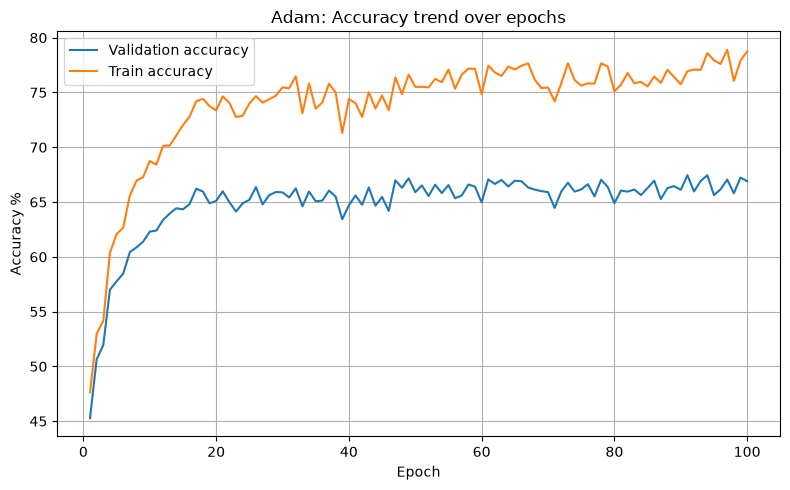

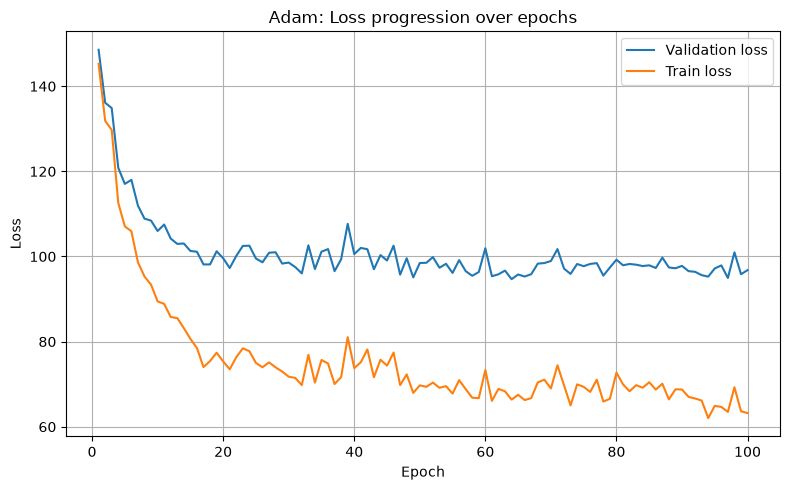

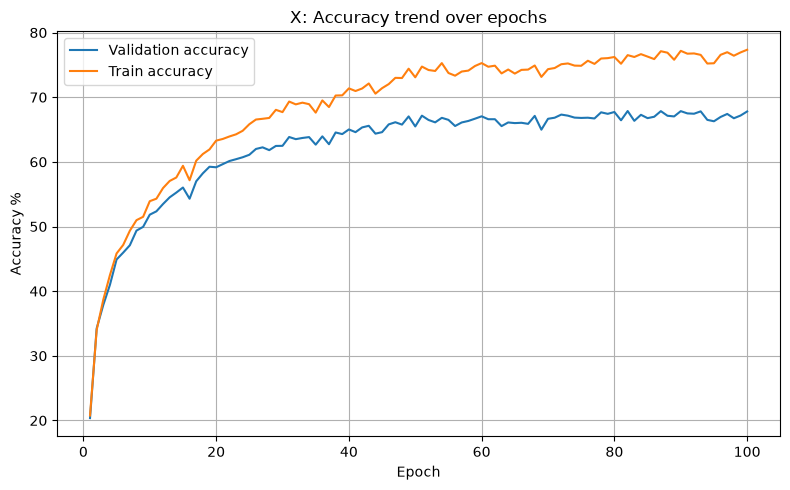

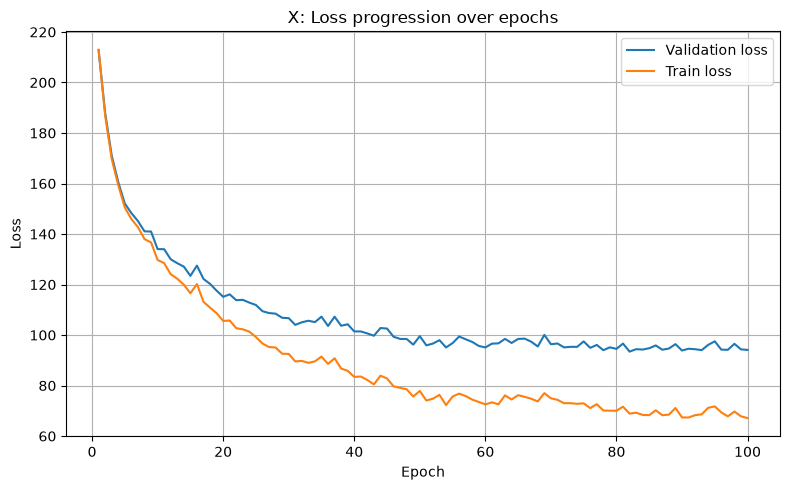

In [ ]:
import matplotlib.pyplot as plt


Adam_val_acc = [acc * 100 for (acc, _) in Adam_val_metrics]
Adam_val_loss = [loss * 100 for (_, loss) in Adam_val_metrics]
Adam_train_acc = [acc * 100 for (acc, _) in Adam_train_metrics]
Adam_train_loss = [loss * 100 for (_, loss) in Adam_train_metrics]


SGD_val_acc = [acc * 100 for (acc, _) in SGD_val_metrics]
SGD_val_loss = [loss * 100 for (_, loss) in SGD_val_metrics]
SGD_train_acc = [acc * 100 for (acc, _) in SGD_train_metrics]
SGD_train_loss = [loss * 100 for (_, loss) in SGD_train_metrics]

epoch_range = range(1, 101)

# Adam Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, Adam_val_acc, label='Validation accuracy')
plt.plot(epoch_range, Adam_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Adam: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Adam Loss
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, Adam_val_loss, label='Validation loss')
plt.plot(epoch_range, Adam_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Adam: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SGD Acccyracy
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, SGD_val_acc, label='Validation accuracy')
plt.plot(epoch_range, SGD_train_acc, label='Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('SGD: Accuracy trend over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SGD Loss
plt.figure(figsize=(8, 5))
plt.plot(epoch_range, SGD_val_loss, label='Validation loss')
plt.plot(epoch_range, SGD_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD: Loss progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Federated Models

Now we reach the point were we can start creating the federated environment, splitting the dataset and training the local models to simulate a federated context.

### Simulating Non-IID-ness

Real clients will never achieve IID-ness over the dataset, meaning that some sort label-skewness is always present and in order to achieve that we'll perform a Dirichlet-based label-skew partition. 

#### FedArtML label-skew protocol


This entails setting up a distribution vector for each of the 10 classes present in our dataset, for our case study we will simulate $K=10$ clients and analyze 4 different concentrations 

$\alpha = 1000,1,0.5, 0.1$

In [5]:
K = 10

tfd = tfp.distributions

alphas = {
    1000: [1000.0]*10,
    1: [1]*10,
    0.5: [0.5]*10,
    0.1: [0.1]*10
}

alphas_class_distributions = {}

for key, value in alphas.items():
    dist = tfd.Dirichlet(alphas[key])
    alphas_class_distributions[key] = dist.sample([10])

#### Client dataset generation

For each alpha we now have a matrix containing label-skew representations for each of the classes (that is, the distribution percentage of samples for each of the classes amongst all clients). 

We must now assign the corresponding local dataset to each client with said alpha matrix, but first we must split our centralized dataset into label-specific sets.

In [12]:

def split_by_class_subset(dataset):
    labels = dataset.tensors[1]
    class_datasets = [None] * 10
    for c in range(10):
        idx = torch.where(labels == c)[0]
        class_datasets[c] = torch.utils.data.Subset(dataset, idx)
    return class_datasets

train_classes_datasets = split_by_class_subset(train_data)
test_classes_datasets = split_by_class_subset(test_data)
val_classes_datasets = split_by_class_subset(val_data)

Once that is done we can calculate the number of samples corresponding to the percentage for each client and split the set.

In [13]:
def fractions_to_counts(fracs, n):  #Our Dirichlet split array represents the percentage of each class the clients will take, so we calculate the actual sample amount
    raw = [float(f) * n for f in fracs]
    counts = [int(x) for x in raw]  
    remainder = n - sum(counts)

    fractional_parts = sorted(
        range(len(raw)), key=lambda i: raw[i] - int(raw[i]), reverse=True
    )
    for i in fractional_parts[:remainder]:
        counts[i] += 1

    assert sum(counts) == n
    return counts

In [ ]:
#This is a horrible piece of code, I'm sorry 

alpha_clients_datasets = {}

#For all distributions we generate K clients that will have a train,test and validation split
for alpha in alphas_class_distributions.keys():
    for i in range(K):
        alpha_clients_datasets[alpha][i] = {"train": [], "test":[], "val":[]}

#For each density (alpha)
for alpha in alphas_class_distributions.keys():
    #We ge the classes distributions
    class_distributions = alphas_class_distributions[alpha]

   
    clients_datasets = alpha_clients_datasets[alpha]

    #For all classes
    for class_index in range(10):

        #We get the number of samples for all the splits of the general dataset
        train_n = len(train_classes_datasets[class_index])
        train_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), train_n)

        test_n = len(test_classes_datasets[class_index])
        test_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), test_n)

        val_n = len(val_classes_datasets[class_index])
        val_counts = fractions_to_counts(class_distributions[class_index].numpy().tolist(), val_n)

        #We split it using the alpha distribution array for the specific class
        train_class_subsets = torch.utils.data.dataset.random_split(train_classes_datasets[class_index], train_counts)
        test_class_subsets = torch.utils.data.dataset.random_split(test_classes_datasets[class_index], test_counts)
        val_class_subsets = torch.utils.data.dataset.random_split(val_classes_datasets[class_index], val_counts)

        #We add the resulting split i to client i
        for client_index in range(K):
            clients_datasets[client_index]["train"].append(train_class_subsets[client_index])
            clients_datasets[client_index]["test"].append(test_class_subsets[client_index])
            clients_datasets[client_index]["val"].append(val_class_subsets[client_index])

    #We transform it into a dataset type
    for client_index in range(K):
        clients_datasets[client_index]["train"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["train"])
        clients_datasets[client_index]["test"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["test"])
        clients_datasets[client_index]["val"] = torch.utils.data.ConcatDataset(clients_datasets[client_index]["val"])


### Quantifying Non-IIDness 

We can now quantify how Non-IDD our federated datasets are by using a couple of different metrics:

1. #### Hellinger Distance

    $$ H(P,Q) = \frac{1}{\sqrt{2}}\sqrt{\sum^{n}_{i=1}{\Bigl(\sqrt{P(i)}-\sqrt{Q(i)}\Bigr)^2}}$$

    In which we measure the dissimilarity between two probability distributions

In [1]:
def HellingerDistance(P,Q):

    sum = 0

    for i in range(len(P)):
        sum += (P[i]**0.5 - Q[i]**0.5)**2

    return 1/(2**0.5) * sum**0.5 

In this case we would like to compare the federated set to an ideal scenario where all data has been equally distributed, note that this metric returns a value ranging from 0 to 1, where 0 means absolute IID and 1 means completely disjoint P,Q sets.

> An ideal IID scenario would have a distribution of $\frac{1}{C}$ for all items, where $C$ is the number of classes.

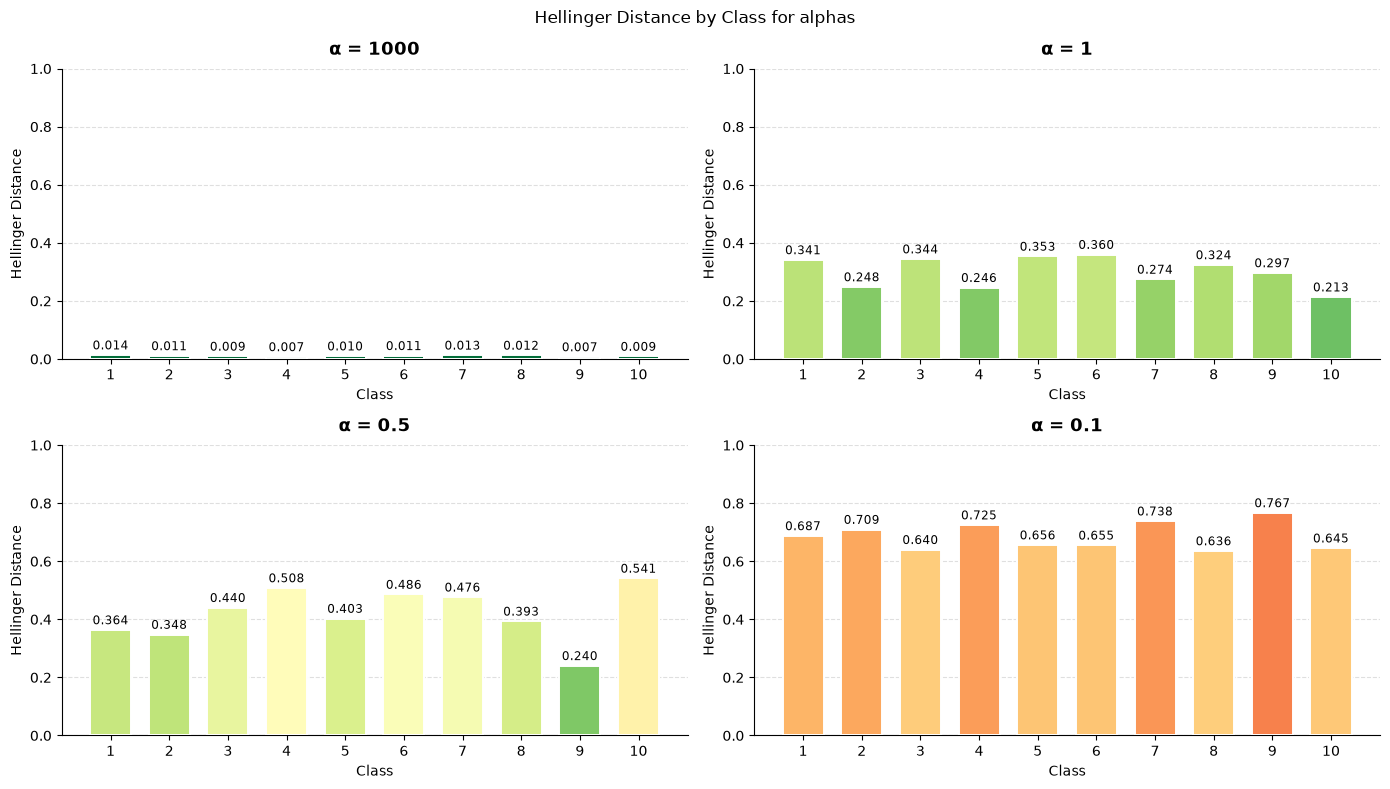

In [ ]:
baseline = [0.1] * 10

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')
norm = mcolors.Normalize(vmin=0, vmax=1)

for i, (alpha, p) in enumerate(alphas_class_distributions.items()):

    row = i // 2
    col = i % 2
    ax = axs[row, col]

    hd_results = []

    for j in range(10):
        hd_results.append(HellingerDistance(p[j].numpy().tolist(), baseline))


    colors = [cmap(norm(v)) for v in hd_results]

    bar_container = ax.bar(
        range(1, 11), hd_results,
        color=colors, edgecolor='white', linewidth=1.4, width=0.7,
        zorder=3
    )
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Hellinger Distance', fontsize=10)
    ax.set_xlabel('Class', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, 11))

    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("Hellinger Distance by Class for alphas")
plt.tight_layout()
plt.show()


We can see how higher concentrations (alpha values) mean fairer distributions in our datasets (near-zero Hellinger distances means closer to IID scenario)

### Local Model training

Having the local datasets we can train each of the client's models and see their performance across the Adam & SGD optimizers

#### Adam-Optimized Model

In [ ]:
best_performing_clients_Adam = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_Adam_metrics = []

    for client_index in range(K):  # For each client

        # We define a model using Adam optimizer
        Adam_model = copy.deepcopy(initial_model)
        Adam_optimizer = torch.optim.Adam(Adam_model.parameters())

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep themetrics
        clients_Adam_metrics.append(run_model(Adam_model, Adam_optimizer, epochs=epochs, train_dataloader=client_train_loader, val_dataloader=client_val_loader))

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_Adam_metrics),
        key=lambda item: item[1][1][epochs - 1][0]  
    )

    best_performing_clients_Adam[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics
    }


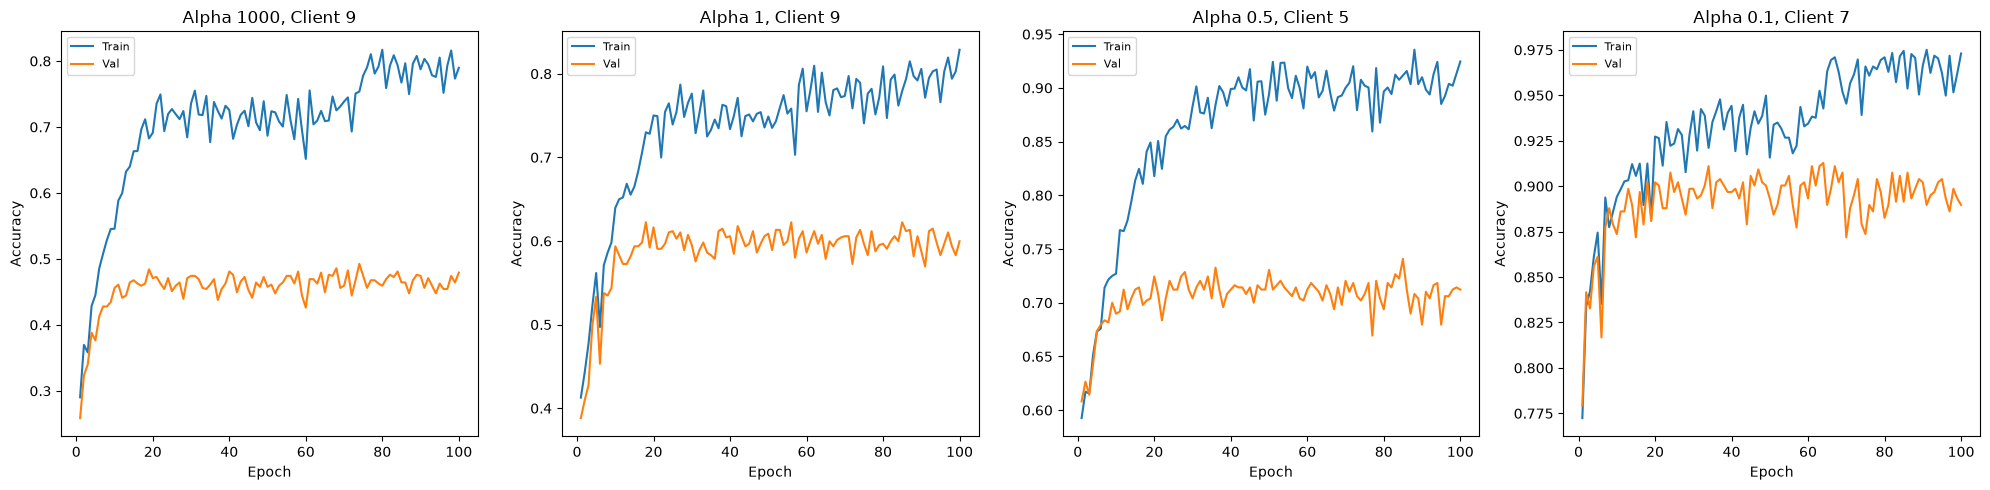

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i,(alpha, dict) in enumerate(best_performing_clients_Adam.items()):
    client_index = dict["client_index"]
    train_metrics, val_metrics = dict["train_metrics"], dict["val_metrics"]
    train_acc = [acc for acc, loss in train_metrics]
    val_acc = [acc for acc, loss in val_metrics]
    epochs_range = range(1, len(train_acc) + 1)

    ax = axes[i]
    ax.plot(epochs_range, train_acc, label="Train", color="tab:blue")
    ax.plot(epochs_range, val_acc, label="Val", color="tab:orange")
    ax.set_title(f"Alpha {alpha}, Client {client_index}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### SGD-Optimized Model

In [ ]:
best_performing_clients_SGD = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_SGD_metrics = []

    for client_index in range(K):  # For each client

        # We define a model using SGD optimizer
        SGD_model = copy.deepcopy(initial_model)
        SGD_optimizer = torch.optim.SGD(SGD_model.parameters())

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep the metrics
        clients_SGD_metrics.append(run_model(SGD_model, SGD_optimizer, epochs=epochs, train_dataloader=client_train_loader, val_dataloader=client_val_loader))

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_SGD_metrics),
        key=lambda item: item[1][1][epochs - 1][0]  
    )

    best_performing_clients_SGD[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics
    }
